# Automating Customer Support with OpenAI API

**ChatSolveAI** is now wired to the reusable `pipeline/` package instead of redefining the same logic inline in the notebook.

---

## Pipeline Overview

| Step | Task | Package Modules |
|------|------|------------------|
| 1 | Build knowledge base embeddings | `pipeline.config`, `pipeline.embeddings` |
| 2 | Query similarity search and response retrieval | `pipeline.embeddings` |
| 3 | Conversational chatbot with fallback generation | `pipeline.chatbot` |
| 4 | Advanced retrieval evaluation | `pipeline.retrieval`, `pipeline.reranker`, `pipeline.evaluate` |
| 5 | End-to-end production diagnostics | `pipeline.classifier`, `pipeline.chatbot` |

---

## Architecture

```text
Customer Query
      |
      v
Intent Classifier
      |
      v
Hybrid Retriever (semantic + lexical)
      |
      v
Cross-Encoder Reranker
      |
      v
Confidence Router
   high -> retrieved answer
   low  -> GPT fallback generation
      |
      v
Structured log + evaluation metrics
```

## Environment Setup

- Load your API key from `.env` or the notebook environment.
- The reranker may download `cross-encoder/ms-marco-MiniLM-L-6-v2` on first use.
- Input files are loaded from the project root or `/mnt/data` via `pipeline.config.data_path()`.

```bash
cp .env.example .env
# then edit .env and set OPENAI_API_KEY=sk-...
```

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pipeline.config import (
    OPENAI_API_KEY,
    EMBED_MODEL,
    CHAT_MODEL,
    RERANK_MODEL,
    CHUNK_SIZE,
    SIM_THRESHOLD,
    data_path,
)
from pipeline.embeddings import embed_in_chunks, normalize_rows, cosine_to_confidence
from pipeline.retrieval import HybridRetriever
from pipeline.reranker import CrossEncoderReranker
from pipeline.classifier import IntentClassifier
from pipeline.chatbot import ChatSolveAI
from pipeline.evaluate import EVAL_SET, evaluate

if not OPENAI_API_KEY:
    raise EnvironmentError(
        "OPENAI_API_KEY not found. Copy .env.example to .env and set the key before running the notebook."
    )

print("Pipeline imports ready")
print(f"Embedding model : {EMBED_MODEL}")
print(f"Chat model      : {CHAT_MODEL}")
print(f"Reranker model  : {RERANK_MODEL}")
print(f"Chunk size      : {CHUNK_SIZE}")
print(f"Sim threshold   : {SIM_THRESHOLD}")


Pipeline imports ready
Embedding model : text-embedding-3-small
Chat model      : gpt-3.5-turbo
Reranker model  : cross-encoder/ms-marco-MiniLM-L-6-v2
Chunk size      : 100
Sim threshold   : 0.78


## Project Files

Quick sanity check that the packaged pipeline can resolve the expected datasets and output files.

In [2]:
required_files = [
    "knowledge_base.csv",
    "processed_queries.csv",
    "predefined_responses.json",
    "chatbot_responses.json",
]

for name in required_files:
    resolved = data_path(name)
    print(f"{name:<28} -> {resolved}")


---
## Task 1 - Knowledge Base Embeddings

Convert `knowledge_base.csv` into embedding vectors stored in `knowledge_embeddings.json` using the shared pipeline utilities.

In [3]:
kb = pd.read_csv(data_path("knowledge_base.csv"))
kb["document_id"] = kb["document_id"].astype(int)
kb["document_text"] = kb["document_text"].astype(str).str.strip()
kb["metadata"] = kb["metadata"].astype(str).fillna("")

print(f"Knowledge base rows : {len(kb):,}")
print(f"Columns             : {list(kb.columns)}")
kb.head(3)


Knowledge base rows : 501
Columns             : ['document_id', 'document_text', 'metadata']


,document_id,document_text,metadata
0,1,This document provides details about payment m...,Requires proof of purchase
1,2,This document provides details about troublesh...,Subject to availability
2,3,This document provides details about refund po...,Limited to US customers


In [4]:
texts = kb["document_text"].tolist()
print(f"Embedding {len(texts):,} documents in chunks of {CHUNK_SIZE}...")

emb_matrix = embed_in_chunks(texts)
print(f"Embedding matrix shape: {emb_matrix.shape}")

records = [
    {
        "document_id": int(row.document_id),
        "document_text": row.document_text,
        "embedding_vector": emb_matrix[i].tolist(),
        "metadata": row.metadata,
    }
    for i, row in enumerate(kb.itertuples(index=False))
]

knowledge_embeddings_path = Path("knowledge_embeddings.json")
with knowledge_embeddings_path.open("w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print(f"Saved {len(records):,} records -> {knowledge_embeddings_path}")
print(f"Embedding dimensions      : {len(records[0]['embedding_vector'])}")


Embedding 501 documents in chunks of 100...
Embedding matrix shape: (501, 1536)
Saved 501 records -> knowledge_embeddings.json
Embedding dimensions      : 1536


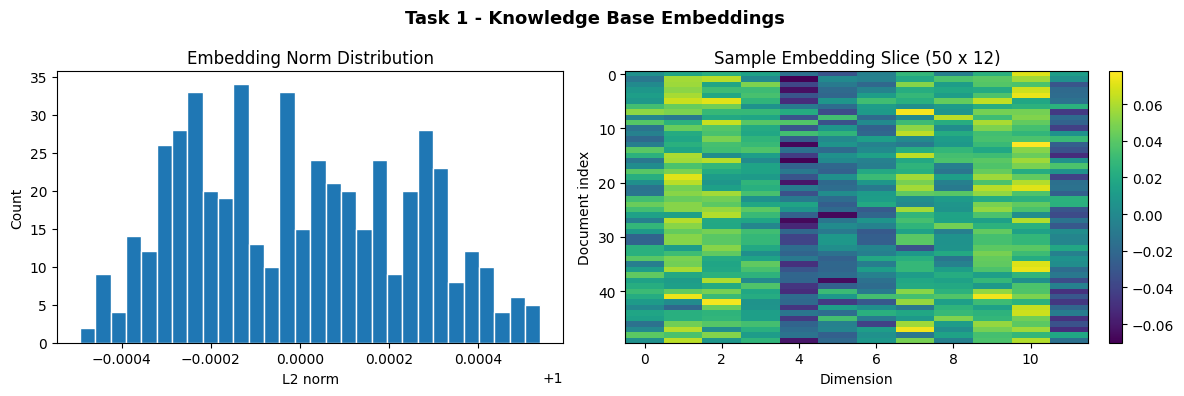

In [5]:
norms = np.linalg.norm(emb_matrix, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Task 1 - Knowledge Base Embeddings", fontsize=13, fontweight="bold")

axes[0].hist(norms, bins=30, color="#1f77b4", edgecolor="white")
axes[0].set_title("Embedding Norm Distribution")
axes[0].set_xlabel("L2 norm")
axes[0].set_ylabel("Count")

sample_dims = emb_matrix[:50, :12]
im = axes[1].imshow(sample_dims, aspect="auto", cmap="viridis")
axes[1].set_title("Sample Embedding Slice (50 x 12)")
axes[1].set_xlabel("Dimension")
axes[1].set_ylabel("Document index")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


---
## Task 2 - Query Similarity Search and Response Retrieval

Use the pipeline embedding helpers to rank predefined responses for every query in `processed_queries.csv`.

In [6]:
TOP_K = 3

queries = pd.read_csv(data_path("processed_queries.csv"))
queries["query_id"] = queries["query_id"].astype(int)
queries["query_text"] = queries["query_text"].astype(str).str.strip()

with open(data_path("predefined_responses.json"), encoding="utf-8") as f:
    predefined = json.load(f)

response_keys = list(predefined.keys())
response_texts = [predefined[k] for k in response_keys]

print(f"Queries loaded           : {len(queries):,}")
print(f"Predefined responses     : {len(response_texts)}")

query_embeddings = normalize_rows(embed_in_chunks(queries["query_text"].tolist()))
response_embeddings = normalize_rows(embed_in_chunks(response_texts))
similarity_matrix = query_embeddings @ response_embeddings.T

print(f"Query embedding shape    : {query_embeddings.shape}")
print(f"Response embedding shape : {response_embeddings.shape}")
print(f"Similarity matrix shape  : {similarity_matrix.shape}")


Queries loaded           : 501
Predefined responses     : 19
Query embedding shape    : (501, 1536)
Response embedding shape : (19, 1536)
Similarity matrix shape  : (501, 19)


In [7]:
results = []

for idx, (qid, qtext) in enumerate(zip(queries["query_id"], queries["query_text"])):
    sims = similarity_matrix[idx]
    top_idx = np.argpartition(-sims, TOP_K - 1)[:TOP_K]
    top_idx = top_idx[np.argsort(-sims[top_idx])]

    results.append(
        {
            "query_id": int(qid),
            "query_text": qtext,
            "top_responses": [response_texts[j] for j in top_idx],
            "confidence_scores": [cosine_to_confidence(float(sims[j])) for j in top_idx],
        }
    )

query_responses_path = Path("query_responses.json")
with query_responses_path.open("w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"Saved {len(results):,} query results -> {query_responses_path}")
pd.DataFrame(results).head(3)


Saved 501 query results -> query_responses.json


,query_id,query_text,top_responses,confidence_scores
0,1,How can I contact customer support?,[You can contact our customer support via emai...,"[0.8336132764816284, 0.6863696873188019, 0.665..."
1,2,can i purchase a gift card,"[Yes, we offer gift cards in various denominat...","[0.8107630014419556, 0.7114585638046265, 0.682..."
2,3,"My order hasn't arrived yet, what should I do?",[Track your order by logging into your account...,"[0.7529384791851044, 0.6713591068983078, 0.666..."


/var/folders/zy/p6ym_xz11zzgmlg6s2vbw0rc0000gn/T/ipykernel_64786/210728046.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([top1, top2, top3], labels=["Top-1", "Top-2", "Top-3"], patch_artist=True)


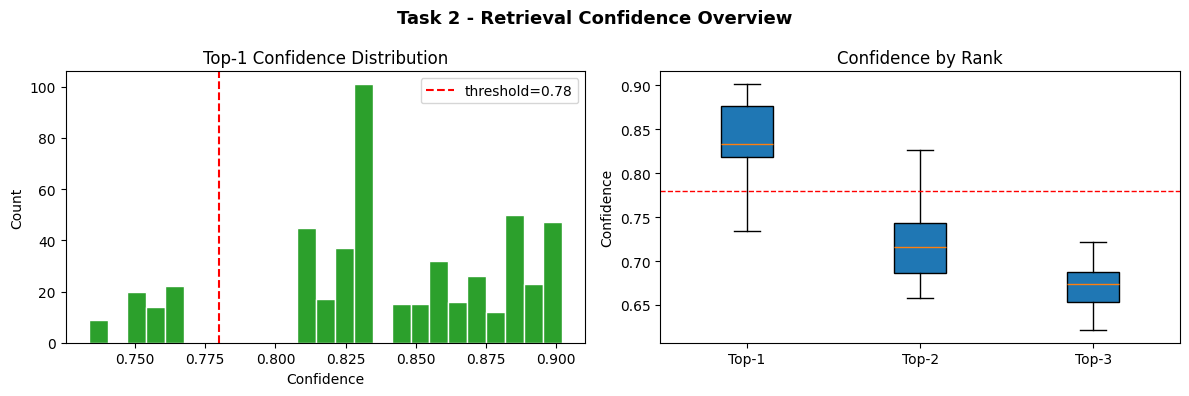

In [8]:
top1 = [row["confidence_scores"][0] for row in results]
top2 = [row["confidence_scores"][1] for row in results]
top3 = [row["confidence_scores"][2] for row in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Task 2 - Retrieval Confidence Overview", fontsize=13, fontweight="bold")

axes[0].hist(top1, bins=25, color="#2ca02c", edgecolor="white")
axes[0].axvline(SIM_THRESHOLD, color="red", linestyle="--", label=f"threshold={SIM_THRESHOLD}")
axes[0].set_title("Top-1 Confidence Distribution")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].boxplot([top1, top2, top3], labels=["Top-1", "Top-2", "Top-3"], patch_artist=True)
axes[1].set_title("Confidence by Rank")
axes[1].set_ylabel("Confidence")
axes[1].axhline(SIM_THRESHOLD, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()


---
## Task 3 - Conversational Chatbot with Fallback Generation

Instead of defining the chatbot inline, build it directly from the packaged classes in `pipeline/`.

In [9]:
with open(data_path("chatbot_responses.json"), encoding="utf-8") as f:
    chatbot_corpus = json.load(f)

chatbot_queries = [row["query_text"] for row in chatbot_corpus]
chatbot_answers = [row["retrieved_response"] for row in chatbot_corpus]

task3_retriever = HybridRetriever(chatbot_queries, chatbot_answers)
task3_reranker = CrossEncoderReranker()
task3_classifier = IntentClassifier()
task3_bot = ChatSolveAI(task3_retriever, task3_reranker, task3_classifier, threshold=SIM_THRESHOLD)

print(f"Chatbot corpus size : {len(chatbot_queries)}")
print("Task 3 pipeline ready")


Loading cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2  (first run downloads ~90 MB)
Chatbot corpus size : 19
Task 3 pipeline ready


In [11]:
task3_demo_queries = [
    "When can I talk to someone from support?",
    "Can I update the card used for billing?",
    "Do you sell event tickets for concerts?",
]

task3_rows = []
for query in task3_demo_queries:
    entry = task3_bot.respond(query)
    task3_rows.append(
        {
            "query": entry["query_text"],
            "source": entry["source"],
            "intent": entry["intent"],
            "confidence": entry["confidence_score"],
            "answer": entry["retrieved_response"],
        }
    )

task3_bot.save_log("sample_chatbot_responses.json")
pd.DataFrame(task3_rows)


✓ Saved 4 interactions → sample_chatbot_responses.json


,query,source,intent,confidence,answer
0,When can I talk to someone from support?,retrieved,technical,0.841041,Our support team is available from 9 AM to 5 P...
1,Can I update the card used for billing?,generated,billing,0.647587,"Yes, you can update your billing card by acces..."
2,Do you sell event tickets for concerts?,generated,billing,0.532032,We do not sell event tickets for concerts.


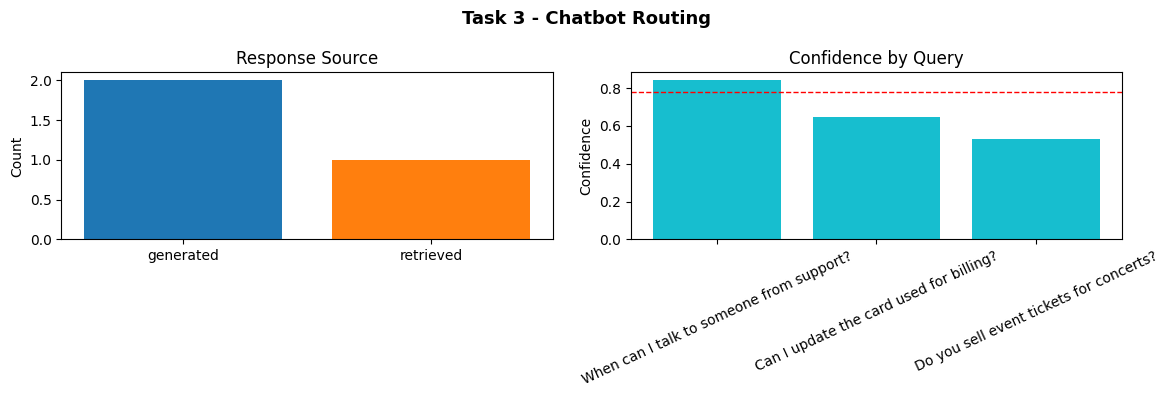

In [12]:
task3_df = pd.DataFrame(task3_rows)
source_counts = task3_df["source"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Task 3 - Chatbot Routing", fontsize=13, fontweight="bold")

axes[0].bar(source_counts.index, source_counts.values, color=["#1f77b4", "#ff7f0e"][: len(source_counts)])
axes[0].set_title("Response Source")
axes[0].set_ylabel("Count")

axes[1].bar(task3_df["query"], task3_df["confidence"], color="#17becf")
axes[1].axhline(SIM_THRESHOLD, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Confidence by Query")
axes[1].set_ylabel("Confidence")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


---
## Task 4 - Advanced Retrieval Evaluation

Use the modular hybrid retriever, cross-encoder reranker, and packaged evaluation metrics to measure retrieval quality with `precision@1`, `precision@3`, `MRR`, and `NDCG`.

In [13]:
advanced_queries = [query for query, _ in EVAL_SET]
advanced_answers = [answer for _, answer in EVAL_SET]

advanced_retriever = HybridRetriever(advanced_queries, advanced_answers)
advanced_reranker = CrossEncoderReranker()
advanced_classifier = IntentClassifier()
advanced_bot = ChatSolveAI(
    advanced_retriever,
    advanced_reranker,
    advanced_classifier,
    threshold=SIM_THRESHOLD,
)

advanced_metrics = evaluate(advanced_retriever, advanced_reranker, EVAL_SET, top_k=5)
metrics_df = pd.DataFrame(
    {
        "metric": list(advanced_metrics.keys()),
        "value": list(advanced_metrics.values()),
    }
)
metrics_df


Loading cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2  (first run downloads ~90 MB)


,metric,value
0,n_queries,15.0
1,precision@1,1.0
2,precision@3,1.0
3,mrr,1.0
4,ndcg@5,1.0


In [14]:
eval_rows = []

for query, expected in EVAL_SET:
    candidates = advanced_retriever.search(query, top_k=20)
    reranked = advanced_reranker.rerank(query, candidates, top_k=5)
    ranked_texts = [candidate["text"] for candidate in reranked]
    rank = next((i + 1 for i, text in enumerate(ranked_texts) if text == expected), None)
    top_conf = reranked[0]["confidence"] if reranked else 0.0

    eval_rows.append(
        {
            "query": query,
            "matched": rank is not None,
            "rank": rank,
            "top_confidence": round(float(top_conf), 4),
            "top_prediction": ranked_texts[0] if ranked_texts else "",
        }
    )

eval_df = pd.DataFrame(eval_rows)
eval_df


,query,matched,rank,top_confidence,top_prediction
0,How do I reset my password?,True,1,1.0000,You can reset your password by clicking on 'Fo...
1,How can I contact customer support?,True,1,1.0000,You can contact our customer support via email...
2,What is your refund policy?,True,1,1.0000,Our refund policy allows refunds within 30 day...
3,How do I track my order?,True,1,1.0000,Track your order by logging into your account ...
4,What payment methods do you accept?,True,1,1.0000,"We accept Visa, MasterCard, PayPal, and Apple ..."
5,Can I change my shipping address after placing...,True,1,0.9997,"Unfortunately, you cannot change the shipping ..."
6,Do you offer international shipping?,True,1,1.0000,"Yes, we offer international shipping to select..."
7,Are there any discounts for first-time customers?,True,1,1.0000,Yes! First-time customers can use code WELCOME...
8,"I received a damaged product, how can I get a ...",True,1,1.0000,"If you received a damaged product, please cont..."
9,How do I update my account details?,True,1,1.0000,You can update your account details in the 'Se...


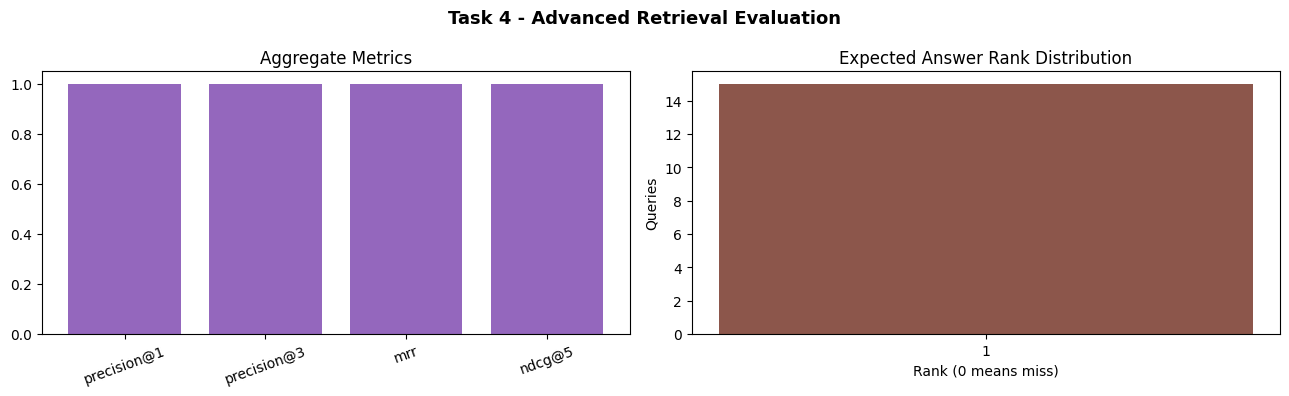

In [15]:
plot_metrics = metrics_df[metrics_df["metric"] != "n_queries"].copy()
plot_metrics["value"] = plot_metrics["value"].astype(float)

rank_counts = eval_df["rank"].fillna(0).astype(int).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Task 4 - Advanced Retrieval Evaluation", fontsize=13, fontweight="bold")

axes[0].bar(plot_metrics["metric"], plot_metrics["value"], color="#9467bd")
axes[0].set_title("Aggregate Metrics")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(rank_counts.index.astype(str), rank_counts.values, color="#8c564b")
axes[1].set_title("Expected Answer Rank Distribution")
axes[1].set_xlabel("Rank (0 means miss)")
axes[1].set_ylabel("Queries")

plt.tight_layout()
plt.show()


---
## Task 5 - End-to-End Production Diagnostics

Run the full advanced pipeline on a mixed set of user questions and inspect intent classification, routing source, confidence, and the top reranked candidate.

In [16]:
task5_queries = [
    "How do I reset my password?",
    "Can I cancel my order after it ships?",
    "Do you offer any discount for first-time customers?",
    "Where is your company headquarters located?",
]

task5_rows = []

for query in task5_queries:
    intent, intent_score = advanced_classifier.classify(query)
    retrieved = advanced_retriever.search(query, top_k=5)
    reranked = advanced_reranker.rerank(query, retrieved, top_k=3)

    advanced_bot.reset()
    entry = advanced_bot.respond(query)

    task5_rows.append(
        {
            "query": query,
            "intent": intent,
            "intent_score": round(float(intent_score), 4),
            "source": entry["source"],
            "response_confidence": entry["confidence_score"],
            "top_candidate": reranked[0]["text"] if reranked else "",
            "final_answer": entry["retrieved_response"],
        }
    )

task5_df = pd.DataFrame(task5_rows)
task5_df


,query,intent,intent_score,source,response_confidence,top_candidate,final_answer
0,How do I reset my password?,account,0.4827,retrieved,1.000000,You can reset your password by clicking on 'Fo...,You can reset your password by clicking on 'Fo...
1,Can I cancel my order after it ships?,shipping,0.3228,retrieved,0.987076,Orders cannot be canceled after they have been...,Orders cannot be canceled after they have been...
2,Do you offer any discount for first-time custo...,billing,0.3661,retrieved,0.958632,Yes! First-time customers can use code WELCOME...,Yes! First-time customers can use code WELCOME...
3,Where is your company headquarters located?,general,0.2325,generated,0.561036,You can contact our customer support via email...,Our company headquarters is located in Silicon...


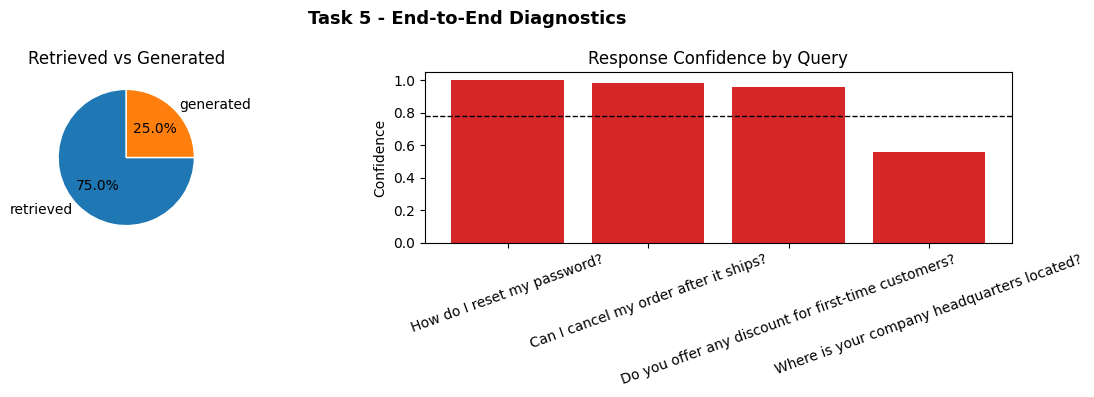

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Task 5 - End-to-End Diagnostics", fontsize=13, fontweight="bold")

source_counts = task5_df["source"].value_counts()
axes[0].pie(
    source_counts.values,
    labels=source_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#1f77b4", "#ff7f0e", "#2ca02c"][: len(source_counts)],
    wedgeprops={"edgecolor": "white"},
)
axes[0].set_title("Retrieved vs Generated")

axes[1].bar(task5_df["query"], task5_df["response_confidence"], color="#d62728")
axes[1].axhline(SIM_THRESHOLD, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Response Confidence by Query")
axes[1].set_ylabel("Confidence")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


---
## Summary and Next Steps

| Area | Outcome |
|------|---------|
| Notebook architecture | Inline logic replaced with imports from `pipeline/` |
| Retrieval basics | Embeddings and top-k retrieval remain reproducible in notebook form |
| Chatbot | `pipeline.chatbot.ChatSolveAI` now drives Task 3 |
| Advanced evaluation | Task 4 measures `precision@1`, `precision@3`, `MRR`, and `NDCG` |
| Production diagnostics | Task 5 inspects intent, routing, confidence, and final answers |

### Natural next steps

1. Compare retrieval metrics before and after threshold tuning.
2. Add a larger labelled evaluation set with paraphrases and out-of-domain questions.
3. Reuse the same advanced corpus and metrics inside the Streamlit app for offline regression checks.
